<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/classification_dt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [1]:
!pip install plotly
!pip install missingno
!pip install scikit-learn
!pip install tabulate
!pip install pandas openpyxl

In [2]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px

from statsmodels.graphics.correlation import plot_corr
from scipy.stats import skew
from scipy.stats import kurtosis
import missingno as msno

#Feature engineering, selection and Model training
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler , LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate


# **Importing Data**

In [3]:
# Reading data
#https://github.com/kwanda2426/projects/blob/df48e82bc9bfe63d3772e6681c3e0ed3d395c57b/Heart_Attack.xlsx
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/drug_data.csv"

In [4]:
df = pd.read_csv(url)


In [5]:
# Showing first 5 lines of data
df.head()


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [6]:
#data columns
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [7]:
# Rows and Columns of data
print('Data has {} rows and {} Columns'.format(df.shape[0],df.shape[1]))
print('')
print('Data has the following columns:')
for i in df.columns:
  print(i)

Data has 200 rows and 6 Columns

Data has the following columns:
Age
Sex
BP
Cholesterol
Na_to_K
Drug


### Data Type of Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


Data set has no missing values.

## Describing the variables

In [9]:
#describing numerical columns
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [10]:
#describing categorical variables
cat_cols = df.select_dtypes(include=["object", "category"])
for i in cat_cols.columns:
  a = df[i].unique()
  print('unique categories for '+ i.upper() + ' is(are) :{}'.format(a))
  print('')

unique categories for SEX is(are) :['F' 'M']

unique categories for BP is(are) :['HIGH' 'LOW' 'NORMAL']

unique categories for CHOLESTEROL is(are) :['HIGH' 'NORMAL']

unique categories for DRUG is(are) :['DrugY' 'drugC' 'drugX' 'drugA' 'drugB']



In [15]:
# Create the data as a list of dictionaries
variables = [
    {"variable": "Age", "description": "Age of the individual."},
    {"variable": "Sex", "description": "Gender of the individual (M = male; F = female)."},
    {"variable": "BP", "description": "Blood Pressure: either HIGH, LOW or NORMAL"},
    {"variable": "Cholesterol", "description": "Cholesterol level in the blood. Either HIGH or NORMAL"},
    {"variable": "Na_to_K", "description": "Sodium to Potassium Ratio."},
    {"variable": "Drug", "description": "Drug type that patient should administer."}
]


# Display the DataFrame
var_desc = pd.DataFrame(variables)
var_desc.reset_index(drop=True, inplace=True)

# Display the DataFrame
print(tabulate(var_desc, headers='keys', tablefmt='pretty'))


+---+-------------+-------------------------------------------------------+
|   |  variable   |                      description                      |
+---+-------------+-------------------------------------------------------+
| 0 |     Age     |                Age of the individual.                 |
| 1 |     Sex     |   Gender of the individual (M = male; F = female).    |
| 2 |     BP      |      Blood Pressure: either HIGH, LOW or NORMAL       |
| 3 | Cholesterol | Cholesterol level in the blood. Either HIGH or NORMAL |
| 4 |   Na_to_K   |              Sodium to Potassium Ratio.               |
| 5 |    Drug     |       Drug type that patient should administer.       |
+---+-------------+-------------------------------------------------------+


The categorical variables will need to be encoded if they will be used in building the model.

- Age and Sex are basic demographic indicators that often correlate with disease risk.
- BP and Cholesterol are key cardiovascular metrics—abnormal levels can signal hypertension or heart disease.
- Na_to_K is a biochemical marker. A high sodium-to-potassium ratio can be linked to increased risk of hypertension and kidney issues.




# **Exploratory Data Analysis**

This method is meant to uncover the underlying structure of a data set and is important for a company because it exposes trends, patterns, and relationships that are not readily apparent.

## **Feature Distribution**
This is meant to discover :
- Relationship between features and target variable. This should help see if a feature that was not caught by correlation because of datatype(especially categorical) has a relationship with the target variable. This helps in encoding categorical features. For an example, with the region in our dataset. It could be that the feature does not affect charges at all, or some regions have more impact than others.

In [16]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


###**Drug Distribution**

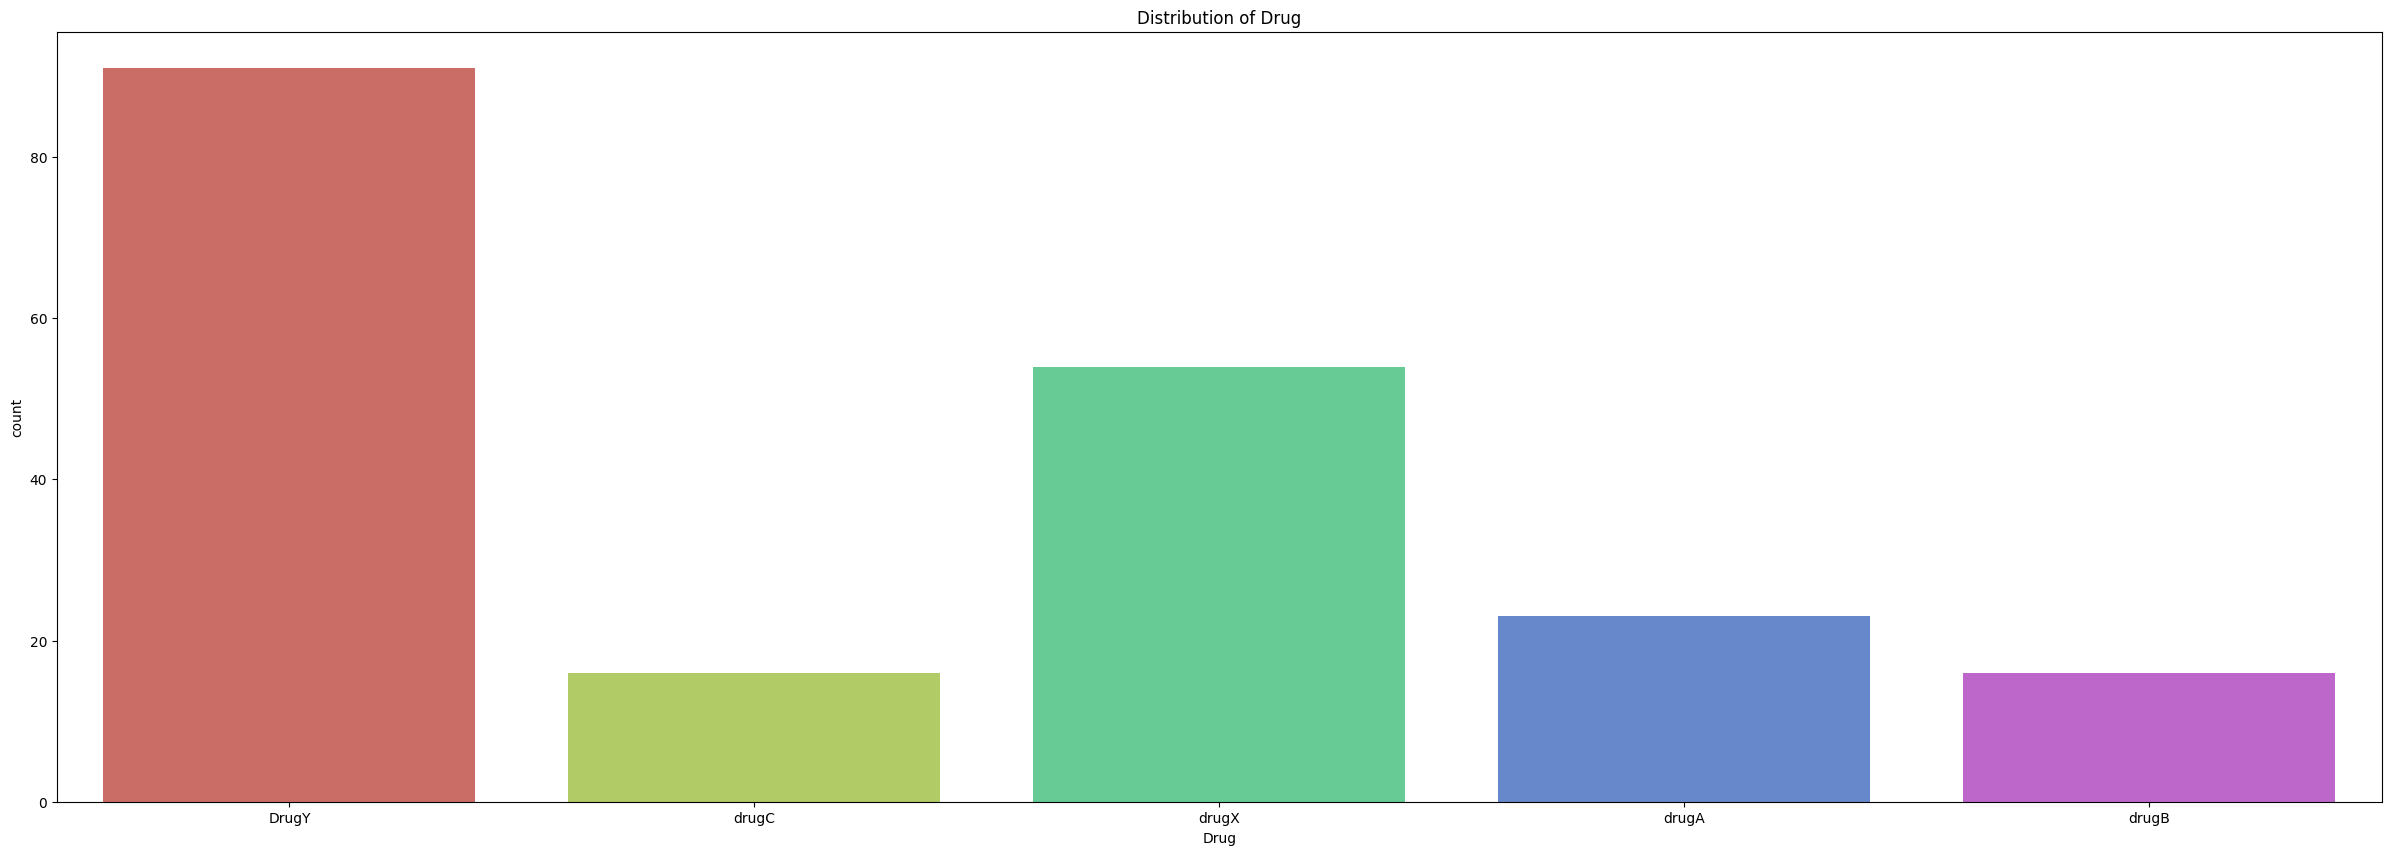

In [28]:
#countplot of sex (between males and females)
df_1 = df.copy()
sns.countplot(x = 'Drug', data = df_1, palette = "hls")
plt.title("Distribution of Drug");

- DrugY and DrugX are the two that are represented the most in this dataset.

###**Gender(sex) Distribution**

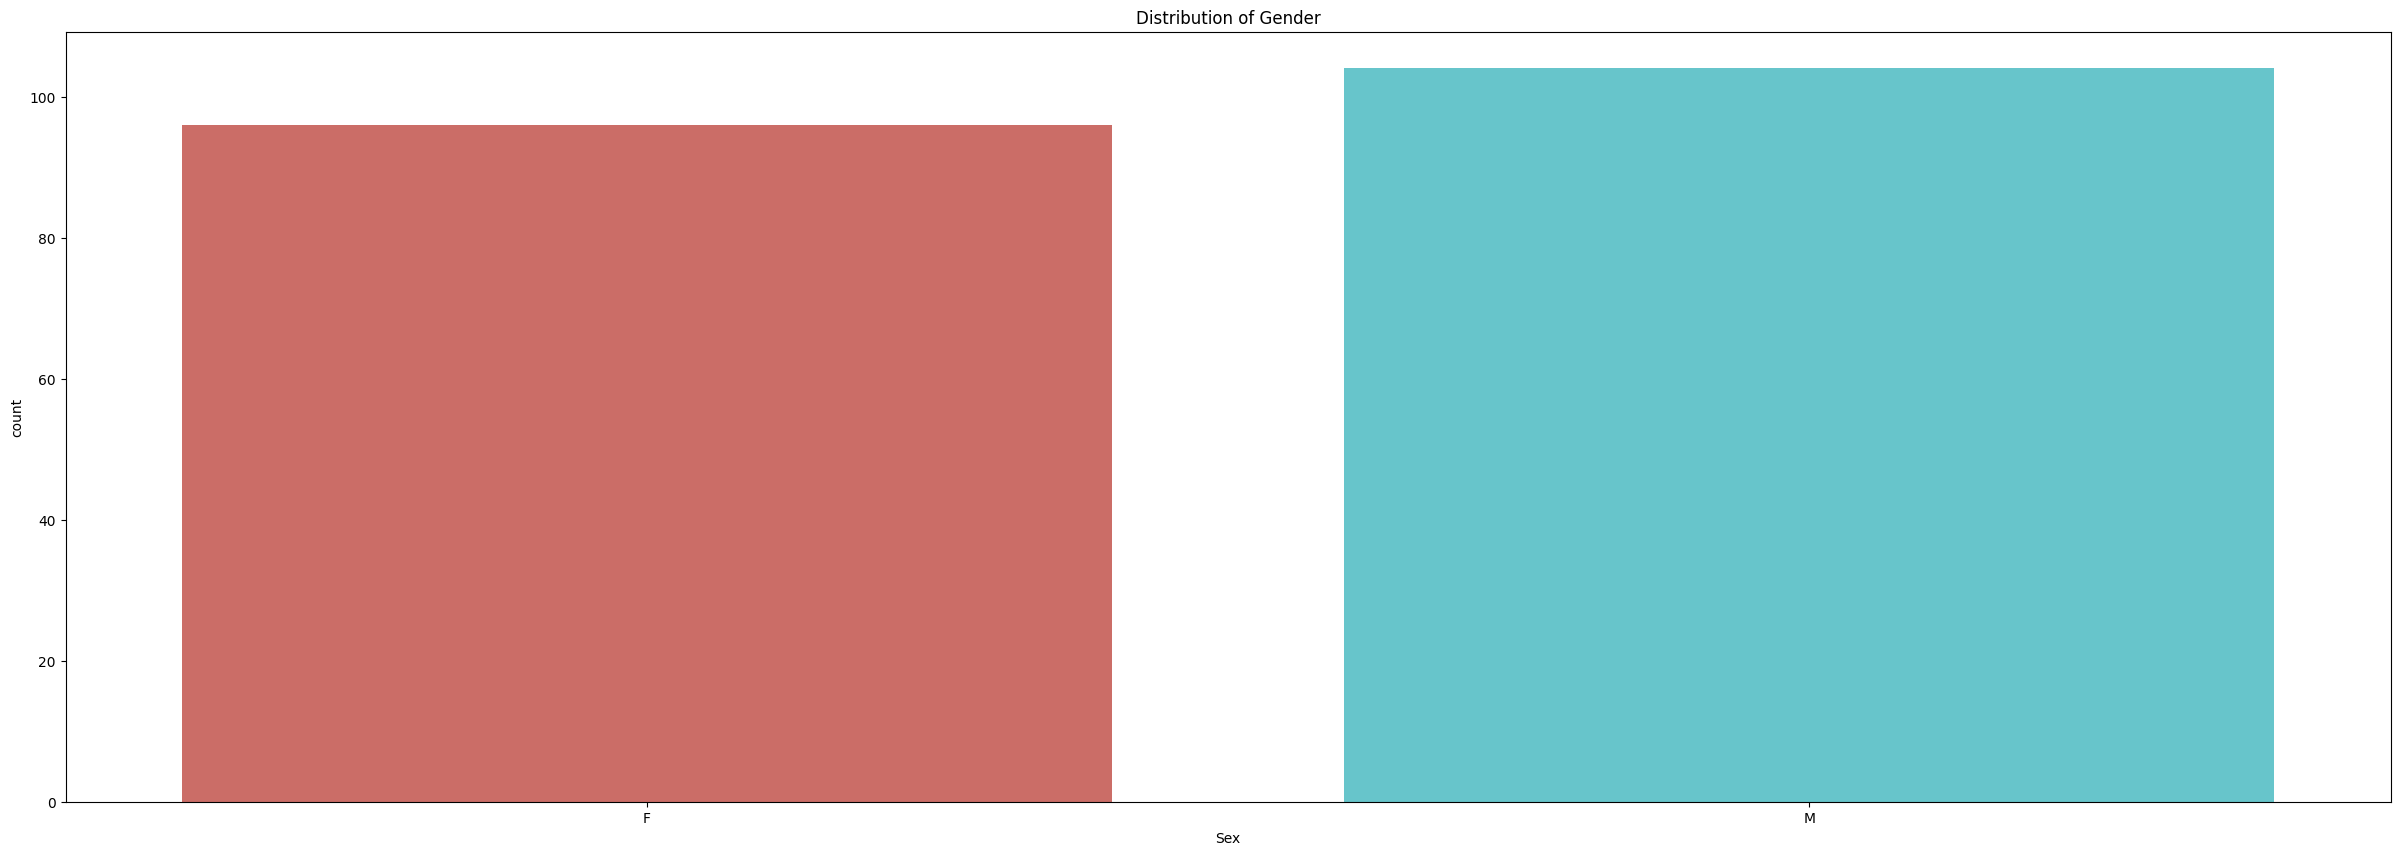

In [26]:
#countplot of sex (between males and females)
df_1 = df.copy()
sns.countplot(x = 'Sex', data = df_1, palette = "hls")
plt.title("Distribution of Gender");

These two groups are fairly equally represented, meaning gender is unlikely to be a strong predictor of drug type.

###**Age Distribution**

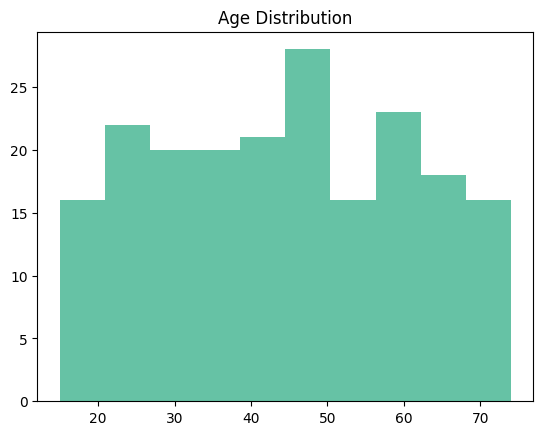

In [19]:
plt.hist(df['Age'],color='#66C2A5')
plt.title("Age Distribution")
plt.show()

- The data ranges between 15 and 74 years. There's a peak between the age of 45 and 50.
- This indicates that middle-aged patients are more represented and might influence drug prescription patterns.

- High likelihood of heart disease in males above the age of 40 and 60.
- As individuals age, cholesterol levels tend to increase.This shift is caused by hormonal changes, reduced metabolic efficiency, and lifestyle factors such as diet and physical activity. These age-related changes in cholesterol contribute to a higher likelihood of developing heart-related diseases, making regular monitoring and lifestyle changes crucial for older individuals.

###**Blood Pressure(BP) Distribution**

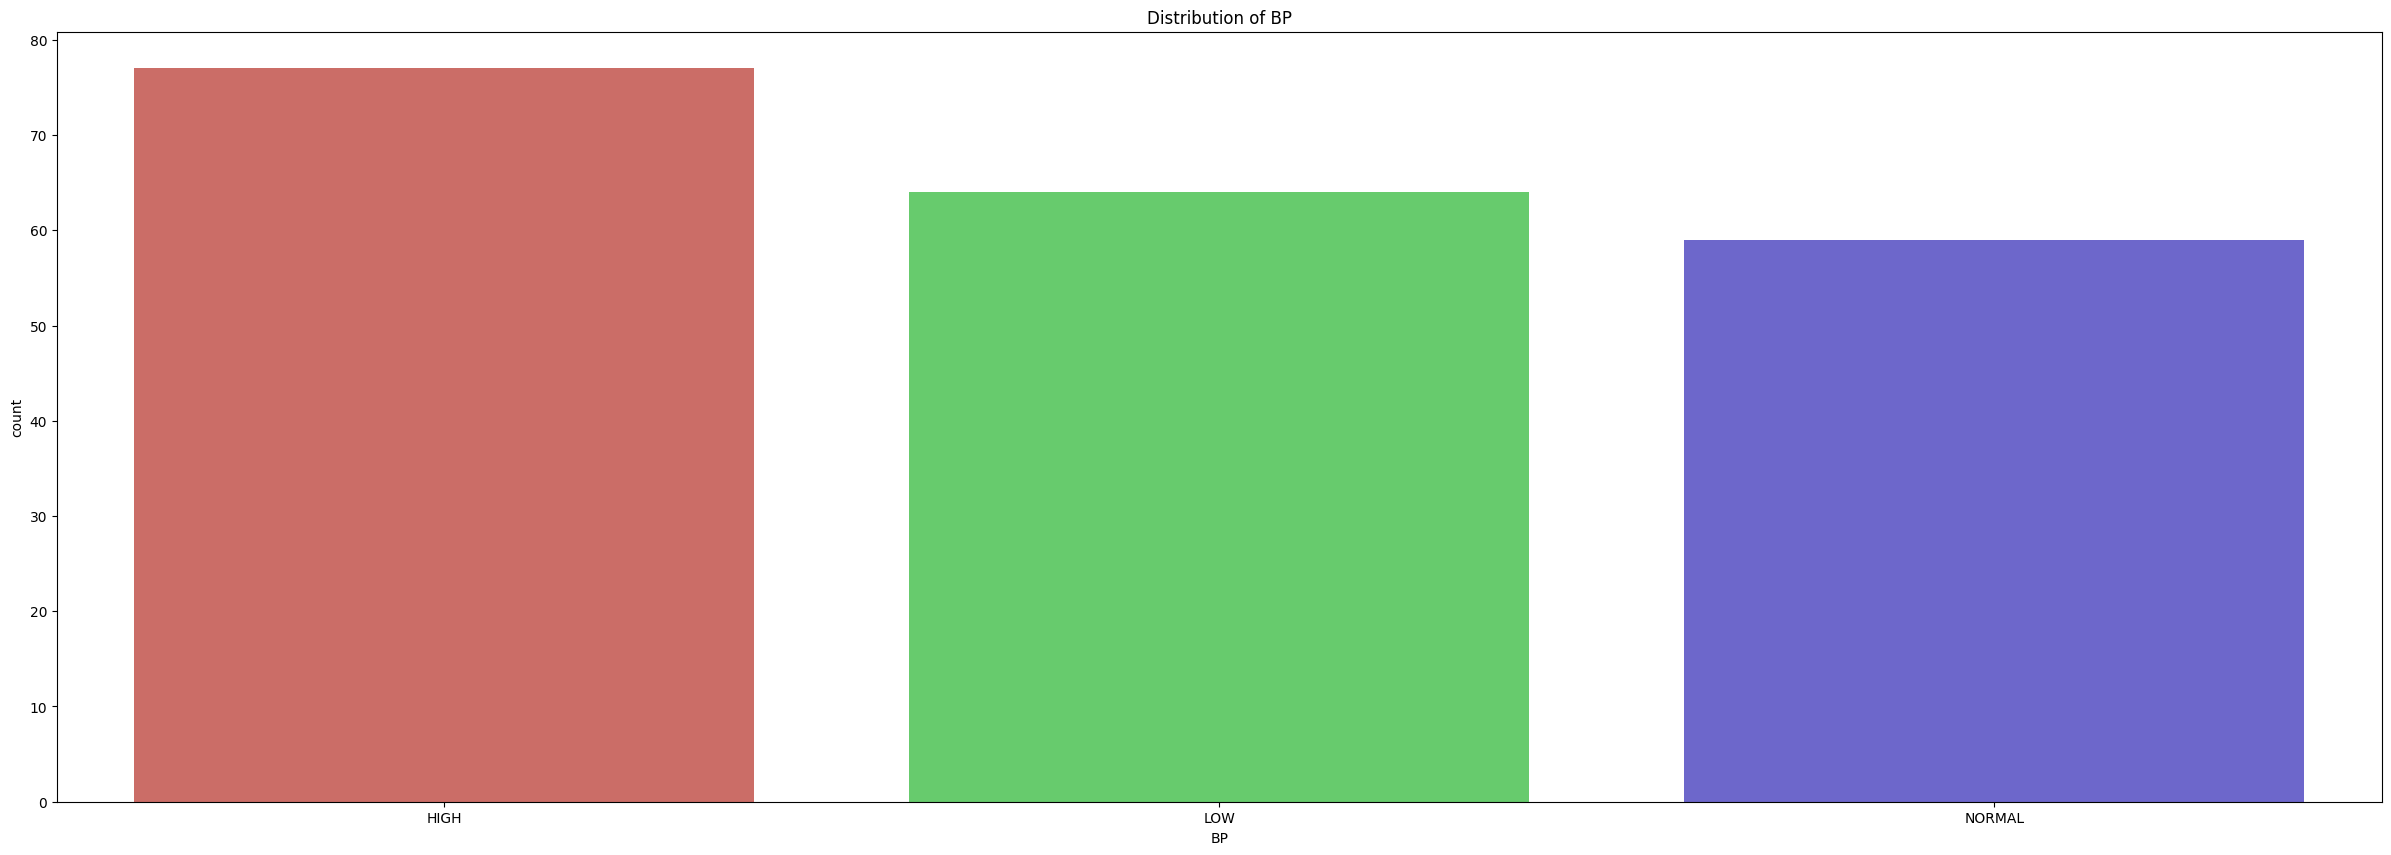

In [24]:
#countplot of sex (between males and females)
df_1 = df.copy()
sns.countplot(x = 'BP', data = df_1, palette = "hls")
plt.title("Distribution of BP");

All categories are fairly represented though HIGH is slightly more than the others.

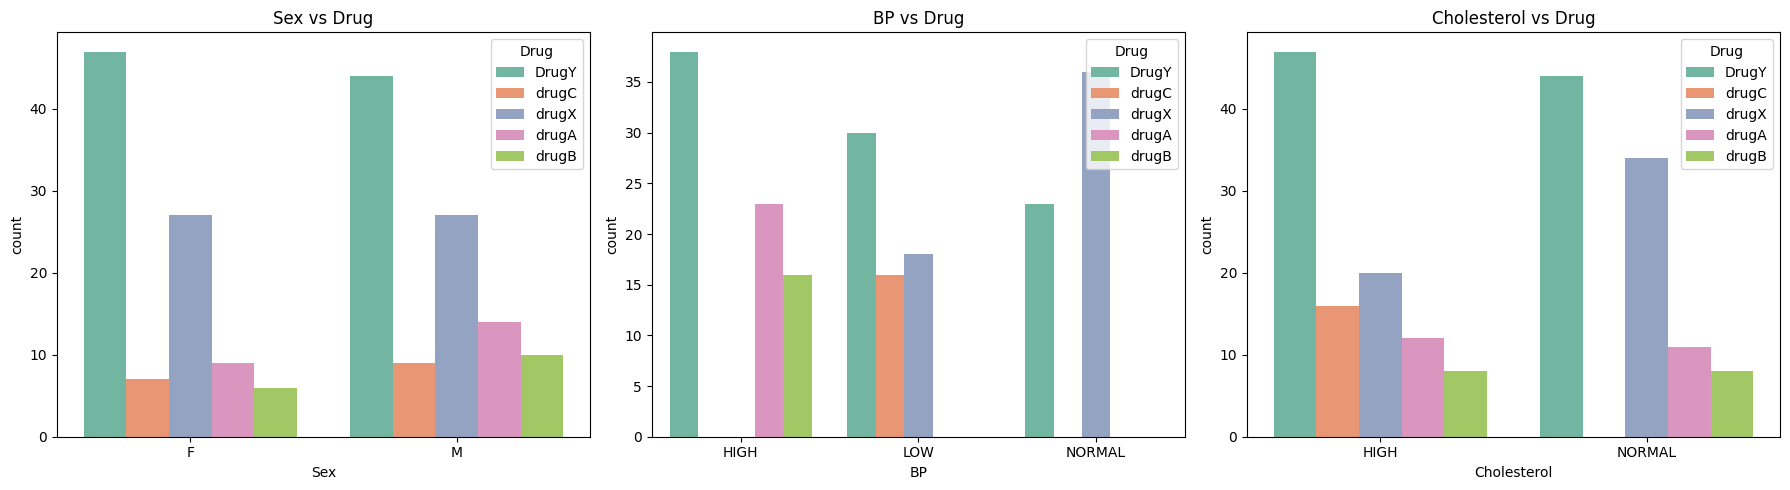

In [29]:
# Drug vs Sex, BP and Cholesterol

df_1 = df.copy()
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(x = 'Sex', hue = 'Drug', data = df_1, palette = 'Set2')
plt.title('Sex vs Drug')

plt.subplot(1, 3, 2)
sns.countplot(x = 'BP', hue = 'Drug', data = df_1, palette = 'Set2')
plt.title('BP vs Drug')

plt.subplot(1, 3, 3)
sns.countplot(x = 'Cholesterol', hue = 'Drug', data = df_1, palette = 'Set2')
plt.title('Cholesterol vs Drug')

plt.tight_layout()
plt.show()

- Overall, DrugY is the one that's ministered the most Across different Matrics.

- Sex: The shape is fairly similar in both genders; limited predictive power.
- BP: Strong impact; High BP strongly linked to DrugY.
- Cholesterol: Highly influential; high cholesterol patients often prescribed DrugY/DrugX. Normal patients do not get DrugC.

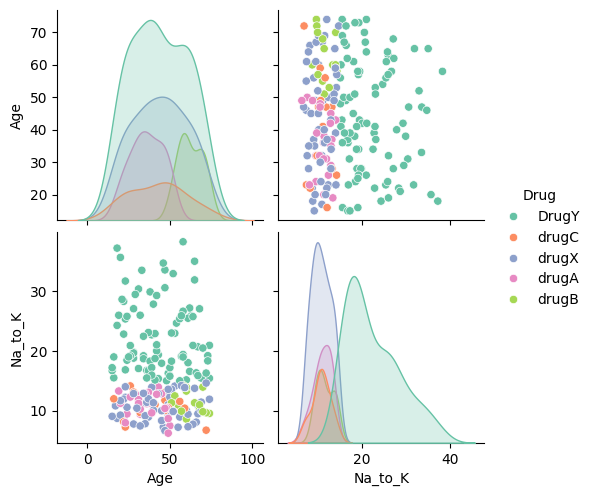

In [31]:
df_1 = df.copy()
sns.pairplot(df_1, vars = ['Age', 'Na_to_K'], hue = 'Drug', diag_kind = 'kde', palette = 'Set2')


###**Key Take Aways**

- Age and Na_to_K ratio are the most important features for distinguishing drug types.
- DrugY is the most prescribed drug, strongly associated with high Na_to_K values and high blood pressure.
- Gender is not a strong predictor due to the balanced male–female distribution.
- Cholesterol and BP have moderate impact, but when combined with Age and Na_to_K, they enhance model performance.
- The dataset suffers from class imbalance (DrugY and DrugX dominate). This must be dealt with in feature engineering.
- Na_to_K is the “golden feature”: it is the strongest indicator for drug classification and should be central in any automated prescription system.

# **Model Building and Testing**

###**Feature Engineering**

The target variable (Drug), cholesterol, BP, Sex are categorical. They must be converted to numeric because , most machine learning algorithms are designed to work with numerical data. Categorical variables, which represent distinct groups or categories cannot be directly processed by these algorithms in their raw text format. Label encoding converts these textual categories into numerical representations, making them compatible with the algorithms.

In [32]:
# Encoding categorica data
df_final = df.copy()
Encoder = LabelEncoder()
df_final['Sex'] = Encoder.fit_transform(df_final['Sex'])
df_final['BP'] = Encoder.fit_transform(df_final['BP'])
df_final['Cholesterol'] = Encoder.fit_transform(df_final['Cholesterol'])
df_final['Drug'] = Encoder.fit_transform(df_final['Drug'])

###**Correlation**

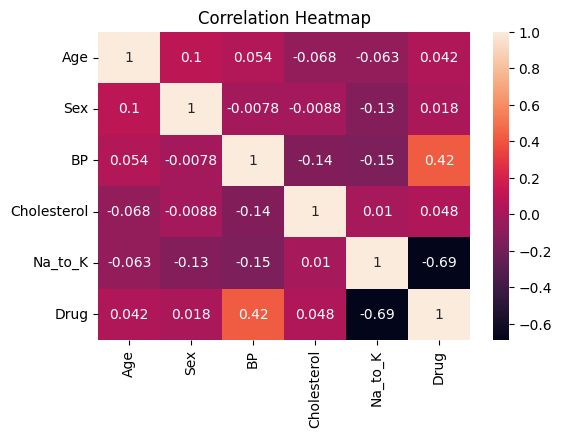

In [34]:
plt.figure(figsize=(6,4))
sns.heatmap(df_final.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# splitting dataset into training and testing
df_data = df.copy()
X = df_data.drop(['target'], axis = 1)
Y = df_data['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80% train and 20% test -- random state = 42, ensure the reproducibility of the data split
x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y, test_size = 0.2, random_state = 42)

In [ ]:
# initialise model
lr_model = LogisticRegression()

#train model
lr_model.fit(x_train, y_train)

LogisticRegression()

In [ ]:
# Making predictions
y_pred_tr = lr_model.predict(x_train)
y_pred_te = lr_model.predict(x_test)

# **Model Evaluation**

**Classification Evaluation Metrics**

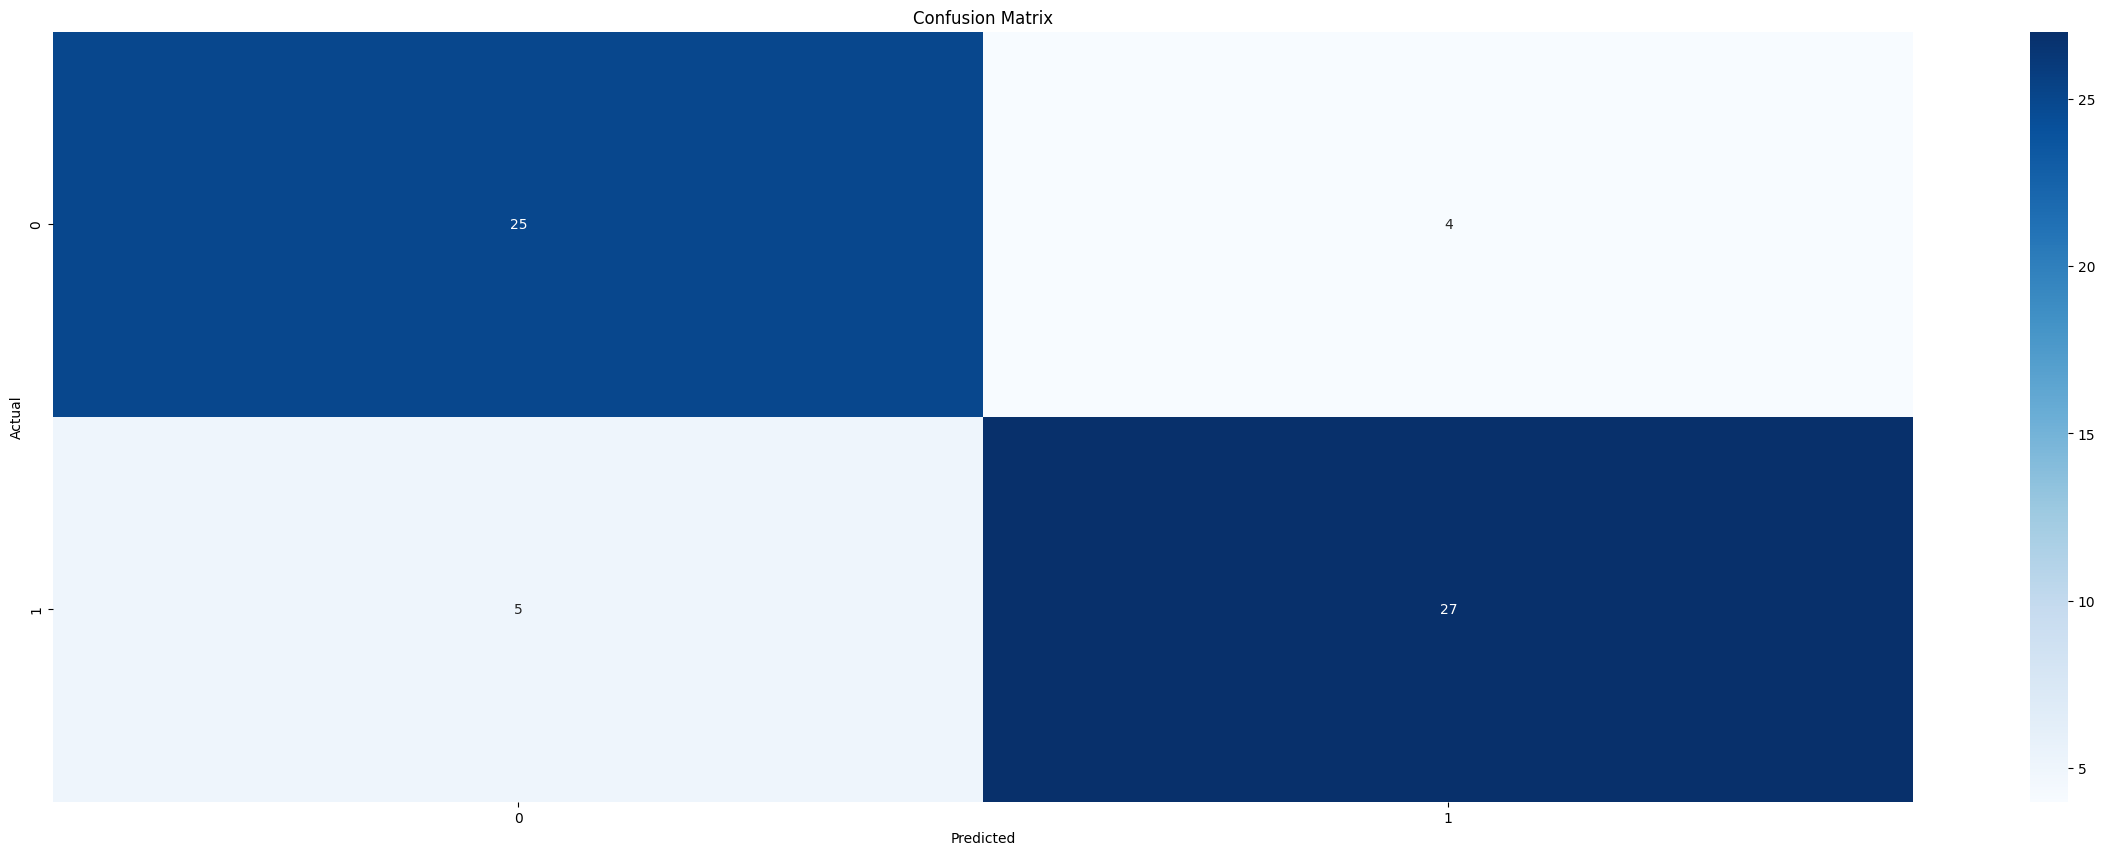

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_te)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Model evaluation
from sklearn.metrics import mean_squared_error

metrics = {
    'Metric': ['Accuracy', 'F-1 Score'],
    'Training': [round(accuracy_score(y_train, y_pred_tr),3), round(f1_score(y_train, y_pred_tr),3)],
    'Testing data': [round(accuracy_score(y_test, y_pred_te),3),round(f1_score(y_test, y_pred_te),3)
    ]
}
# Create the DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df.reset_index(drop=True, inplace=True)

# Display the DataFrame
print(tabulate(metrics_df, headers = 'keys', tablefmt = 'pretty'))

+---+-----------+----------+--------------+
|   |  Metric   | Training | Testing data |
+---+-----------+----------+--------------+
| 0 | Accuracy  |  0.864   |    0.852     |
| 1 | F-1 Score |  0.881   |    0.857     |
+---+-----------+----------+--------------+
